# Phase 2 — Part 1: Tabular Q-Learning (Single Agent)

**RiseUp Asia — Practical Assignment | Python AI Researcher / Intern track**

This notebook implements a complete **tabular Q-learning** solution for a single
agent in an `n × n` grid world, built **entirely from scratch**. Only the Python
standard library, NumPy and Matplotlib are used — **no** reinforcement-learning
libraries (Gym, Gymnasium, Stable-Baselines, Ray RLlib, TensorFlow, PyTorch,
Keras, …).

The whole experiment is reproducible: one seed (`SEED = 42`) controls the
environment sampling, the episode generator, epsilon-greedy exploration and the
unbiased tie-breaking during evaluation. Run the notebook **from top to bottom**
(Kernel → Restart & Run All) to reproduce every number and figure below.

## 1. Problem Definition

### 1.1 The task

A single agent starts on a random cell of an `n × n` grid. The world contains:

* **`A`** — an item whose location is drawn randomly **at the start of every
  episode** (it changes between episodes);
* **`B`** — a fixed target at the bottom-right corner `(n-1, n-1)` (zero-based).

The agent can only execute the eight **movement** actions (up / down / left /
right plus the four diagonals). When the agent steps onto `A` the item is picked
up automatically; when the agent then reaches `B` while carrying the item, the
episode ends **successfully**.

### 1.2 Objective

Reach `B` with the item using as **few steps as possible**, *regardless of where
`A` is located*. Because `A` moves every episode, the agent must learn the
*general* skill “go to the item, then go to the target”, not memorize one item
cell.

### 1.3 Success criterion (full-mark target)

For the default `5 × 5` grid the assignment defines:

```
100% of scenarios solved
every solved scenario uses  <= 10  steps
training uses             < 20 000 episodes
```

All three conditions are verified at the end of this notebook **from the actual
measured runs** and the notebook prints `PASSED` / `FAILED` accordingly. Nothing
is fabricated.

## 2. Environment Design

The environment is a standalone class named `GridWorld`. It contains **only
world dynamics** (movement, automatic pickup, automatic delivery, termination)
and **no learning logic whatsoever** — Q-learning lives in a completely separate
`QLearningAgent` class.

### 2.1 Grid
* A square `n × n` grid with **zero-based** coordinates `(row, col)`, where
  `row` ∈ `[0, n-1]` is the vertical axis (**0 = top row**) and `col` ∈ `[0, n-1]`
  is the horizontal axis (**0 = left column**).
* The size `n` is a constructor parameter, so grids such as `3 × 3`, `5 × 5` and
  `7 × 7` can all be created. The default experiment below uses `n = 5`.

### 2.2 Agent
* The agent occupies exactly one cell.
* At `reset()` a **random starting cell** is drawn each episode (note: the agent
  may also start on `A` or on `B`; see Edge cases in the Discussion).

### 2.3 Item `A`
* Drawn **randomly** at `reset()`, anew every episode.
* It is **never** placed on the target `B` — one cell can host only one object,
  and this keeps “pickup” and “delivery” unambiguous.
* While the agent carries the item, `A`’s stored coordinates remain in the
  state, but the `carrying` flag tells the policy that the item travels with
  the agent (the coordinates are then only used for the final delivery logic
  and visualisation).

### 2.4 Target `B`
* Fixed at `(n-1, n-1)` (bottom-right corner) by default; the position is
  configurable through the `target` parameter for experiments.
* Reaching `B` **while carrying** the item ends the episode successfully.

### 2.5 Actions
Exactly the eight movement actions of the assignment:

| action       | vector    |
|--------------|-----------|
| `up`         | `(-1,  0)`|
| `down`       | `( 1,  0)`|
| `left`       | `( 0, -1)`|
| `right`      | `( 0,  1)`|
| `up_left`    | `(-1, -1)`|
| `up_right`   | `(-1,  1)`|
| `down_left`  | `( 1, -1)`|
| `down_right` | `( 1,  1)`|

There are **no** `pickup`, `drop`, `collect` or `deliver` actions.

### 2.6 Automatic Pickup and Delivery
* Stepping onto `A` sets `carrying = True` — the pickup is **automatic**.
* Stepping onto `B` while `carrying` ends the episode — the delivery is
  **automatic**.
* Because `A ≠ B` by construction, both events can never fire on the same step,
  but the reward code combines them additively so the logic remains general.

In [1]:
import time

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

print("numpy      :", np.__version__)
print("matplotlib :", matplotlib.__version__)

numpy      : 2.4.4
matplotlib : 3.11.0


In [2]:
# ----------------------------------------------------------------------------
# Configuration -- single place to change the whole experiment.
# ----------------------------------------------------------------------------
SEED = 42                                # reproducibility seed

GRID_SIZE = 5                            # n of the "n x n" grid (default n = 5)
TARGET = (GRID_SIZE - 1, GRID_SIZE - 1)  # B = (n-1, n-1), zero-based

# Training budget (kept under the assignment limit of 20 000 episodes)
EPISODES = 19_000
MAX_STEPS = 60            # safety cap per episode (theoretical max for n=5 is 8)

# Q-learning hyperparameters
ALPHA = 0.3               # learning rate
GAMMA = 0.95              # discount factor
EPSILON_START = 1.0       # start fully exploratory
EPSILON_MIN = 0.05        # keep a small amount of exploration forever
EPSILON_DECAY = 0.9995    # multiplicative decay, applied once per episode

MOVING_AVG_WINDOW = 200   # window for the moving-average plots

config = {
    "seed": SEED,
    "grid_size": GRID_SIZE,
    "target": TARGET,
    "episodes": EPISODES,
    "max_steps": MAX_STEPS,
    "alpha": ALPHA,
    "gamma": GAMMA,
    "epsilon_start": EPSILON_START,
    "epsilon_min": EPSILON_MIN,
    "epsilon_decay": EPSILON_DECAY,
}
for key, value in config.items():
    print(f"{key:>16}: {value}")

            seed: 42
       grid_size: 5
          target: (4, 4)
        episodes: 19000
       max_steps: 60
           alpha: 0.3
           gamma: 0.95
   epsilon_start: 1.0
     epsilon_min: 0.05
   epsilon_decay: 0.9995


## 3. Reward Structure

The reward is returned by the environment at every step:

| event                        | reward  |
|------------------------------|---------|
| valid movement               | `-1`    |
| invalid / out‑of‑grid move   | `-2`    |
| automatic pickup (step on A) | `+10`   |
| successful delivery (B)      | `+100`  |

### Why this design
* **`-1` per valid move** gives the agent a direct incentive to minimise the
  number of steps → shortest paths. Without a per‑step penalty the agent would
  be indifferent to wandering.
* **`-2` for an invalid move** makes the boundary un‑attractive: an invalid
  attempt is *worse* than a valid step, so the policy learns to stay inside the
  grid (the state is unchanged, so it also learns that boundaries are dead
  ends, not shortcuts).
* **`+10` for the pickup** creates a clear reward gradient towards `A`, which is
  essential because the item moves every episode and the agent must “find” it
  from any starting cell.
* **`+100` for the delivery** dominates every other signal: once the agent
  reaches `B` with the item, the episode is over and the return is strongly
  positive. Any number of extra steps is still worth taking, so the agent never
  gives up.
* The per-step cost also makes **diagonal moves** naturally attractive whenever
  they reduce the Chebyshev distance (two legs collapsed into one step).

This design is the “strong starting design” of the assignment. It was **kept
unchanged** because (a) training converges reliably and (b) the exhaustive test
below reaches 100 % success with ≤ 10 steps in every scenario. If it had
failed, the first things to inspect would have been epsilon decay, gamma and
the terminal-state handling — exactly what Section 24 of the spec prescribes.

## 4. State Representation

The agent’s state is the tuple

```
s = (agent_row, agent_col, item_row, item_col, carrying)
```

* `agent_row, agent_col` — current position of the agent (zero-based);
* `item_row, item_col` — current position of the item `A`;
* `carrying` — `0/1`, whether the agent already picked the item up.

### Why this is a sufficient (Markov) state
* From `agent_row/-col` the agent knows where it stands and can reason about the
  next move and about boundaries;
* From `item_row/-col` it knows where to go **before** the pickup;
* `carrying` tells the agent which *phase* it is in: *go to `A`* (`carrying=0`)
  or *go to `B`* (`carrying=1`) — this is exactly what changes the optimal
  action for the same coordinates;
* The target `B` is **fixed and known** for the whole run, so it does not need to
  be part of the state;
* Everything the agent needs to choose an action is inside the tuple, so the
  state is Markov (memoryless) — the optimal action depends only on these five
  values.

The tuple is **hashable**, so it can be a dictionary key directly; the
implementation additionally maps it to *indexes* of a NumPy array
`Q[agent_r, agent_c, item_r, item_c, carrying, action]`.
This makes the Q-table compact and fast (pure integer indexing, no dict hashing
inside the hot training loop, and it is arguably easier to explain).

## 5. Environment Implementation

`GridWorld` is deliberately a *pure* environment:
* `reset()` → returns the starting state;
* `step(action)` → returns `(next_state, reward, done)`;
* it knows nothing about Q-learning, exploration or policies.

The action-space convention used everywhere below: actions are **integers**
`0..7`, mapped through `GridWorld.ACTION_NAMES` to human-readable names. This is
exactly what the Q-table needs (an integer action axis).

In [3]:
class GridWorld:
    """An n x n grid world with one agent, one item 'A' and one fixed
    target 'B'.

    The class only describes the world dynamics (movement, automatic
    pickup, automatic delivery, termination). It contains no learning
    logic -- Q-learning is implemented separately in QLearningAgent.
    """

    # name -> (row delta, col delta)
    ACTIONS = {
        "up":           (-1,  0),
        "down":         ( 1,  0),
        "left":         ( 0, -1),
        "right":        ( 0,  1),
        "up_left":      (-1, -1),
        "up_right":     (-1,  1),
        "down_left":    ( 1, -1),
        "down_right":   ( 1,  1),
    }
    ACTION_NAMES = list(ACTIONS.keys())

    # Reward structure (documented in section 3)
    MOVE_REWARD = -1.0
    INVALID_REWARD = -2.0
    PICKUP_REWARD = 10.0
    DELIVERY_REWARD = 100.0

    def __init__(self, n=5, target=None, seed=None):
        """Create an n x n grid.

        Parameters
        ----------
        n : int        -- grid size (each side), default 5.
        target : tuple -- position of B, default (n-1, n-1).
        seed : int     -- seed for the internal RNG (random placement).
        """
        if n < 2:
            raise ValueError("grid must be at least 2x2 so that item A can exist")
        self.n = n
        self.target = (n - 1, n - 1) if target is None else tuple(target)
        r, c = self.target
        if not (0 <= r < n and 0 <= c < n):
            raise ValueError(f"target {self.target} is outside a {n}x{n} grid")
        self.rng = np.random.default_rng(seed)   # RNG for random placement only
        self.agent_pos = None
        self.item_pos = None
        self.carrying = None
        self.done = True

    # ------------------------------------------------------------------
    # public API
    # ------------------------------------------------------------------
    def reset(self, start=None, item=None):
        """Start a new episode.

        If `start` / `item` are given they are used directly (useful for
        tests and for exhaustive evaluation); otherwise they are sampled
        randomly.  Returns the starting state tuple.
        """
        self.agent_pos = self._pick_cell("start", start)
        self.item_pos = self._pick_item(item)
        # Edge case: the agent may spawn directly on A -> automatic pickup.
        self.carrying = (self.agent_pos == self.item_pos)
        self.done = False
        return self.get_state()

    def step(self, action):
        """Apply one movement action (integer index into ACTION_NAMES).

        Returns (next_state, reward, done).
        """
        if self.done:
            raise RuntimeError("episode already over: call reset() first")

        dr, dc = self.ACTIONS[self.ACTION_NAMES[action]]
        nr, nc = self.agent_pos[0] + dr, self.agent_pos[1] + dc

        # Invalid move: out of the grid. Agent stays, no state change.
        if not (0 <= nr < self.n and 0 <= nc < self.n):
            return self.get_state(), self.INVALID_REWARD, False

        self.agent_pos = (nr, nc)
        reward = self.MOVE_REWARD

        # Automatic pickup (no separate "pickup" action exists).
        if not self.carrying and self.agent_pos == self.item_pos:
            self.carrying = True
            reward += self.PICKUP_REWARD

        # Successful delivery: reach B while carrying the item.
        if self.carrying and self.agent_pos == self.target:
            reward += self.DELIVERY_REWARD
            self.done = True

        return self.get_state(), reward, self.done

    def get_state(self):
        """Hashable Markov state (agent pos, item pos, carrying flag)."""
        return (self.agent_pos[0], self.agent_pos[1],
                self.item_pos[0], self.item_pos[1],
                int(self.carrying))

    # ------------------------------------------------------------------
    # helpers (random placement / validation)
    # ------------------------------------------------------------------
    def _pick_cell(self, what, pos):
        """Return a random cell, or validate a user-supplied cell."""
        if pos is None:
            return tuple(int(x) for x in self.rng.integers(0, self.n, size=2))
        pos = tuple(pos)
        if not (0 <= pos[0] < self.n and 0 <= pos[1] < self.n):
            raise ValueError(f"{what} {pos} is outside the {self.n}x{self.n} grid")
        return pos

    def _pick_item(self, item):
        """Return a random item cell (never on target B) or validate one."""
        if item is None:
            choices = [(r, c) for r in range(self.n) for c in range(self.n)
                       if (r, c) != self.target]
            return tuple(choices[int(self.rng.integers(0, len(choices)))])
        item = tuple(item)
        if not (0 <= item[0] < self.n and 0 <= item[1] < self.n):
            raise ValueError(f"item {item} is outside the {self.n}x{self.n} grid")
        if item == self.target:
            raise ValueError("item A may not share the target cell B")
        return item

## 6. Environment Verification

Before any learning, the environment itself is verified independently with a
series of assertions. If any assertion fails the notebook stops here — training
is only allowed to start once every check printed `[PASS]`.

In [4]:
print("Running environment verification ...\n")

# --- 6.1 Grid creation ------------------------------------------------
env = GridWorld(n=5, seed=SEED)
assert env.n == 5 and env.target == (4, 4), "default 5x5 target must be (4,4)"
assert GridWorld(n=7).target == (6, 6)
assert GridWorld(n=3, target=(1, 1)).target == (1, 1)   # configurable target
print("[PASS] grid creation; target defaults to (n-1,n-1) and is configurable")

# --- 6.2 Reset: valid, hashable state; random start and item -------------
state = env.reset()
assert isinstance(state, tuple) and len(state) == 5, "state must be a 5-tuple"
ar, ac, ir, ic, carrying = state
assert all(0 <= v < 5 for v in (ar, ac, ir, ic)), "coordinates in range"
assert (ir, ic) != (4, 4), "item A must never spawn on target B"
assert carrying in (0, 1)
print(f"[PASS] reset returns a valid hashable state {state}")

starts, items = set(), set()
for _ in range(200):
    s = env.reset()
    starts.add((s[0], s[1]))
    items.add((s[2], s[3]))
assert len(starts) > 1, "random starting positions must vary"
assert len(items) > 1, "random item locations must vary"
print(f"[PASS] over 200 resets: {len(starts)}/25 distinct starts, "
      f"{len(items)} distinct item cells")

Running environment verification ...

[PASS] grid creation; target defaults to (n-1,n-1) and is configurable
[PASS] reset returns a valid hashable state (0, 3, 3, 0, 0)
[PASS] over 200 resets: 25/25 distinct starts, 24 distinct item cells


In [5]:
# --- 6.3 All eight actions ---------------------------------------------
expected = {   # from centre (2,2) of the 5x5 grid, item A placed far away
    "up": (1, 2), "down": (3, 2), "left": (2, 1), "right": (2, 3),
    "up_left": (1, 1), "up_right": (1, 3),
    "down_left": (3, 1), "down_right": (3, 3),
}
env = GridWorld(n=5, seed=SEED)
for i, name in enumerate(GridWorld.ACTION_NAMES):
    env.reset(start=(2, 2), item=(4, 0))          # (4,0) is away from B(4,4)
    state, reward, done = env.step(i)
    assert (state[0], state[1]) == expected[name], (name, state)
    assert reward == env.MOVE_REWARD, "plain move must return -1"
    assert not done, "a plain move must not end the episode"
print("[PASS] all eight movement vectors applied correctly")

# --- 6.4 Boundary handling / invalid moves -----------------------------
i_up = GridWorld.ACTION_NAMES.index("up")
i_left = GridWorld.ACTION_NAMES.index("left")
i_dr = GridWorld.ACTION_NAMES.index("down_right")
env.reset(start=(0, 0), item=(4, 0))
state, reward, done = env.step(i_up)
assert (state[0], state[1]) == (0, 0), "agent must not leave a 5x5 grid"
assert reward == env.INVALID_REWARD and not done
print(f"[PASS] invalid 'up' from corner -> reward {reward}, position unchanged")

env.reset(start=(0, 0), item=(4, 0))
state, reward, done = env.step(i_left)
assert (state[0], state[1]) == (0, 0) and reward == env.INVALID_REWARD
print("[PASS] invalid 'left' behaves identically")

env.reset(start=(0, 0), item=(4, 0))
state, reward, done = env.step(i_dr)
assert (state[0], state[1]) == (1, 1) and reward == env.MOVE_REWARD
print("[PASS] diagonal 'down_right' from the corner is a valid move")

[PASS] all eight movement vectors applied correctly
[PASS] invalid 'up' from corner -> reward -2.0, position unchanged
[PASS] invalid 'left' behaves identically
[PASS] diagonal 'down_right' from the corner is a valid move


In [6]:
# --- 6.5 Automatic pickup and carrying state ---------------------------
env = GridWorld(n=5, seed=SEED)
env.reset(start=(1, 1), item=(1, 2))                # A is one step right
state, reward, done = env.step(GridWorld.ACTION_NAMES.index("right"))
assert not done, "stepping on A must not terminate the episode"
assert state[4] == 1, "agent must now carry the item"
assert reward == env.MOVE_REWARD + env.PICKUP_REWARD
print(f"[PASS] stepping on A -> carrying=True, reward {reward} (move + pickup)")

# --- 6.6 Delivery, episode termination ----------------------------------
env = GridWorld(n=5, seed=SEED)
env.reset(start=(3, 3), item=(3, 3))                # start directly on A
assert env.carrying, "starting on A must auto-pickup"
state, reward, done = env.step(GridWorld.ACTION_NAMES.index("down_right"))
assert (state[0], state[1]) == (4, 4), "must arrive at B"
assert done, "delivery must end the episode"
assert reward == env.MOVE_REWARD + env.DELIVERY_REWARD
print(f"[PASS] walking into B while carrying -> done, reward {reward}")

try:
    env.step(0)
    raise AssertionError("step() after termination must raise")
except RuntimeError:
    print("[PASS] step() after termination raises RuntimeError (no silent moves)")

# --- 6.7 Impossible configurations are rejected -------------------------
try:
    env.reset(item=(4, 4))
    raise AssertionError("item on target B must be rejected")
except ValueError as error:
    print(f"[PASS] item on target B rejected: {error}")

[PASS] stepping on A -> carrying=True, reward 9.0 (move + pickup)
[PASS] walking into B while carrying -> done, reward 99.0
[PASS] step() after termination raises RuntimeError (no silent moves)
[PASS] item on target B rejected: item A may not share the target cell B


In [7]:
# --- 6.8 Parameterised grid sizes and edge cases ------------------------
for n in (2, 3, 7):
    g = GridWorld(n=n, seed=SEED)
    s = g.reset()
    assert len(s) == 5 and g.target == (n - 1, n - 1)
    assert all(0 <= v < n for v in (s[0], s[1], s[2], s[3]))
print("[PASS] parameterised grids 2x2, 3x3 and 7x7 work")

env = GridWorld(n=5, seed=SEED)
s = env.reset(start=(4, 4), item=(0, 0))    # agent starts on B WITHOUT item
assert not env.carrying and not env.done, "spawn on B without A must continue"
print("[PASS] starting on B without the item: episode continues (must fetch A)")

print("\nAll environment checks passed -> safe to start training.")

[PASS] parameterised grids 2x2, 3x3 and 7x7 work
[PASS] starting on B without the item: episode continues (must fetch A)

All environment checks passed -> safe to start training.


## 7. Q-Learning Implementation

All learning code is written from scratch — a NumPy-array Q-table, an
epsilon-greedy policy and the standard one-step TD update. No RL framework is
used anywhere.

### 7.1 Q-Table
* Shape `[n, n, n, n, 2, 8]` — indexes are
  `(agent_row, agent_col, item_row, item_col, carrying, action)`.
* For the default `5 × 5` grid that is `5·5·5·5·2·8 = 10 000` parameters — a
  genuinely tabular representation that covers the complete state space.
* All entries start at `0.0`. For a fixed state, the *greedy* action is
  `argmax_a Q[state, a]`.

### 7.2 Epsilon-Greedy Policy
With probability `ε` pick a uniformly random action (exploration); otherwise
pick the action with the highest Q-value (exploitation). **Ties** between
maximal Q-values are broken by a uniform random draw among the tied actions, so
the agent never has an artificial bias towards an early action name.

### 7.3 Q-Value Update
Standard off-policy TD update:

```
Q(s,a)  <-  Q(s,a) + alpha * [ r + gamma * max_a' Q(s',a') - Q(s,a) ]
```

For a *terminal* successful transition the bootstrap term
`gamma * max_a' Q(s', a')` is **zero** (there are no future rewards), i.e. the
update becomes `Q(s,a) <- Q(s,a) + alpha * (r - Q(s,a))`. Returning the raw
delivery reward only on this final step is exactly what makes the delivered
state worth +100 and lets the value propagate backwards.

In [8]:
class QLearningAgent:
    """Tabular Q-learning agent (from scratch, no RL framework)."""

    def __init__(self, n, alpha=0.3, gamma=0.95, epsilon_start=1.0,
                 epsilon_min=0.05, epsilon_decay=0.9995, seed=42):
        self.n = n
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        n_actions = len(GridWorld.ACTION_NAMES)
        # Q[agent_r, agent_c, item_r, item_c, carrying, action]
        self.q_table = np.zeros((n, n, n, n, 2, n_actions))
        self.rng = np.random.default_rng(seed)   # exploration + tie-breaking

    @staticmethod
    def _idx(state):
        """Map a state tuple to integer indexes of the Q-table."""
        ar, ac, ir, ic, carrying = state
        return ar, ac, ir, ic, carrying

    def choose_action(self, state, greedy=False):
        """Epsilon-greedy action selection; `greedy=True` disables exploration."""
        idx = self._idx(state)
        q_row = self.q_table[idx]
        if not greedy and self.rng.random() < self.epsilon:
            return int(self.rng.integers(0, self.q_table.shape[-1]))
        return self._best_action(q_row)

    def _best_action(self, q_row):
        """Argmax with unbiased random tie-breaking among equal Q-values."""
        best = float(np.max(q_row))
        tied = np.flatnonzero(np.isclose(q_row, best))
        return int(self.rng.choice(tied))

    def update(self, state, action, reward, next_state, done):
        """Standard Q-learning (off-policy TD) update for one transition."""
        idx = self._idx(state)
        current_q = self.q_table[idx][action]
        if done:
            td_target = reward                 # no future returns after delivery
        else:
            best_next = float(np.max(self.q_table[self._idx(next_state)]))
            td_target = reward + self.gamma * best_next
        self.q_table[idx][action] = current_q + self.alpha * (td_target - current_q)

    def decay_epsilon(self):
        """Multiplicative epsilon decay, floored at epsilon_min."""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

In [9]:
def train_q_learning(env, agent, episodes, max_steps, seed=42):
    """Train the agent for a number of episodes.

    Every episode starts with a NEW random start position and a NEW random
    item location (never on B), so the agent can never memorise a single
    configuration.

    Returns (episode_rewards, episode_steps, episode_success).
    """
    rng = np.random.default_rng(seed)     # independent from exploration RNG
    episode_rewards, episode_steps, episode_success = [], [], []

    for _ in range(episodes):
        # --- fresh random scenario -----------------------------------
        start = tuple(int(x) for x in rng.integers(0, env.n, size=2))
        item = tuple(int(x) for x in rng.integers(0, env.n, size=2))
        while item == env.target:
            item = tuple(int(x) for x in rng.integers(0, env.n, size=2))

        state = env.reset(start=start, item=item)
        total_reward = 0.0
        done = False

        # --- episode roll-out (max max_steps safety) -------------------
        for step in range(max_steps):
            action = agent.choose_action(state)
            next_state, reward, done = env.step(action)
            agent.update(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward
            if done:
                break

        agent.decay_epsilon()
        episode_rewards.append(total_reward)
        episode_steps.append(step + 1 if done else max_steps)
        episode_success.append(done)

    return episode_rewards, episode_steps, episode_success


def moving_average(values, window):
    """Simple centred-free moving average via convolution ('valid' mode)."""
    values = np.asarray(values, dtype=float)
    if window <= 1:
        return values
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")

## 8. Training

Running the loop defined above with the configuration of Section 1:

1. every episode samples a **fresh random** `(start, item)` pair;
2. the agent rolls out at most `MAX_STEPS` steps, choosing actions
   epsilon-greedily;
3. after every step the Q-table is updated with the standard TD rule;
4. `epsilon` is decayed once per episode.

The environment is used only through `reset()`/`step()` — it never learns.

In [10]:
env = GridWorld(n=GRID_SIZE, seed=SEED)
agent = QLearningAgent(n=GRID_SIZE, alpha=ALPHA, gamma=GAMMA,
                       epsilon_start=EPSILON_START,
                       epsilon_min=EPSILON_MIN,
                       epsilon_decay=EPSILON_DECAY, seed=SEED)

t0 = time.time()
episode_rewards, episode_steps, episode_success = train_q_learning(
    env, agent, episodes=EPISODES, max_steps=MAX_STEPS, seed=SEED)
elapsed = time.time() - t0

print(f"Trained {EPISODES} episodes in {elapsed:.1f} s")
print(f"Final epsilon                    : {agent.epsilon:.4f}")
print(f"Q-table shape                    : {agent.q_table.shape}")
print(f"Non-zero Q entries               : {int(np.count_nonzero(agent.q_table))}")
print(f"Fraction of Q entries updated    : {np.mean(agent.q_table != 0):.1%}")
last = 500
print(f"Success rate of last {last} episodes : "
      f"{sum(episode_success[-last:]) / last:.1%}")

Trained 19000 episodes in 7.8 s
Final epsilon                    : 0.0500
Q-table shape                    : (5, 5, 5, 5, 2, 8)
Non-zero Q entries               : 8757
Fraction of Q entries updated    : 87.6%
Success rate of last 500 episodes : 100.0%


In [11]:
# --- Learning-progress metrics -----------------------------------------
mv_reward = moving_average(episode_rewards, MOVING_AVG_WINDOW)
mv_steps = moving_average(episode_steps, MOVING_AVG_WINDOW)

print(f"{'episodes':>10} | {'mean reward':>11} | {'mean steps':>10} | {'success':>8}")
block = 2_000
for lo in range(0, EPISODES, block):
    hi = min(lo + block, EPISODES)
    r = np.mean(episode_rewards[lo:hi])
    s = np.mean(episode_steps[lo:hi])
    ok = sum(episode_success[lo:hi]) / (hi - lo) * 100
    print(f"{lo:>5}-{hi:<4} | {r:11.2f} | {s:10.2f} | {ok:7.1f}%")

  episodes | mean reward | mean steps |  success
    0-2000 |       67.55 |      23.72 |    86.2%
 2000-4000 |      101.60 |       7.71 |   100.0%
 4000-6000 |      103.47 |       6.16 |   100.0%
 6000-8000 |      103.78 |       5.81 |   100.0%
 8000-10000 |      103.77 |       5.82 |   100.0%
10000-12000 |      103.82 |       5.74 |   100.0%
12000-14000 |      103.83 |       5.65 |   100.0%
14000-16000 |      103.77 |       5.75 |   100.0%
16000-18000 |      103.79 |       5.77 |   100.0%
18000-19000 |      103.74 |       5.68 |   100.0%


## 9. Testing Methodology

### 9.1 Exhaustive scenario set for the default 5 × 5 world
The target `B` is fixed at `(4,4)`. The agent may start on any of the 25 cells
and the item `A` may be on any of the 24 remaining cells → `25 × 24 = 600`
scenarios. **All 600 are evaluated** — not a sample.

### 9.2 Fair testing (no learning during evaluation)
* Evaluation uses **pure greedy** action selection (`epsilon = 0`).
* The Q-table is snapshotted before evaluation and compared afterwards; any
  change would raise an `AssertionError`. Evaluation therefore never modifies
  the learned policy.
* Each evaluation roll-out has a permissive step cap (larger than the ≤10-step
  requirement) so that a failure means “cannot solve”, never “timed out”.

### 9.3 Theoretical lower bound (used only for verification)
Because diagonal moves exist, the shortest path between two cells is their
**Chebyshev distance** `max(|Δrow|, |Δcol|)`. Hence the theoretical optimum for a
scenario is

```
d(start, A) + d(A, B)
```

This formula is used **only to verify** the learned trajectories — the policy
itself comes exclusively from the Q-table. The learned result and the
theoretical optimum are reported separately.

In [12]:
def greedy_rollout(env, agent, start, item, max_steps=60):
    """Run ONE episode of the *learned* policy without any learning.

    Returns (success, steps_taken, trajectory, total_reward).
    """
    state = env.reset(start=start, item=item)
    trajectory = [state]
    total_reward = 0.0
    done = False
    steps = 0
    for _ in range(max_steps):
        action = agent.choose_action(state, greedy=True)   # epsilon = 0
        next_state, reward, done = env.step(action)
        trajectory.append(next_state)
        total_reward += reward
        steps += 1
        state = next_state
        if done:
            break
    return done, steps, trajectory, total_reward


def evaluate_scenarios(env, agent, scenarios, max_steps=60):
    """Run greedy rollouts for all (start, item) scenarios.

    Guards against accidental learning: raises if the Q-table changed.
    """
    q_before = agent.q_table.copy()          # snapshot
    records = []
    for start, item in scenarios:
        success, steps, trajectory, total_reward = greedy_rollout(
            env, agent, start, item, max_steps)
        records.append({"start": start, "item": item, "success": success,
                        "steps": steps, "trajectory": trajectory,
                        "reward": total_reward})
    if not np.array_equal(agent.q_table, q_before):
        raise AssertionError("Q-table was modified during evaluation!")
    return records

In [13]:
# --- Exhaustive 600-scenario test for the 5x5 grid -----------------------
cells = [(r, c) for r in range(GRID_SIZE) for c in range(GRID_SIZE)]
items = [pos for pos in cells if pos != TARGET]
scenarios = [(start, item) for item in items for start in cells]
print(f"Exhaustive test set: {len(cells)} starts x {len(items)} items "
      f"= {len(scenarios)} scenarios (target B fixed at {TARGET})")

records = evaluate_scenarios(env, agent, scenarios, max_steps=50)
print("Evaluation finished. Q-table verified unchanged (assertion passed).")

Exhaustive test set: 25 starts x 24 items = 600 scenarios (target B fixed at (4, 4))
Evaluation finished. Q-table verified unchanged (assertion passed).


## 10. Evaluation Metrics

From the 600 greedy roll-outs we compute:
* **success rate** — fraction of scenarios solved;
* **average / maximum / minimum successful steps**;
* **number of failed scenarios**;
* a comparison with the **theoretical optimum** (Chebyshev path length) to show
  how close the learned policy is to optimal.

In [14]:
def chebyshev(a, b):
    """Number of steps of the theoretical shortest path (diagonals allowed)."""
    return max(abs(a[0] - b[0]), abs(a[1] - b[1]))


def summarize(records, episodes_used):
    """Summarise evaluation records into a small metrics dict."""
    n = len(records)
    successes = [r for r in records if r["success"]]
    steps = [r["steps"] for r in successes]
    return {
        "scenarios": n,
        "success_rate": len(successes) / n * 100.0,
        "avg_successful_steps": float(np.mean(steps)) if steps else float("nan"),
        "max_successful_steps": int(max(steps)) if steps else 0,
        "min_successful_steps": int(min(steps)) if steps else 0,
        "failed": n - len(successes),
        "training_episodes": episodes_used,
    }

summary = summarize(records, EPISODES)
print("Evaluation summary (5x5, exhaustive 600 scenarios):")
for key, value in summary.items():
    print(f"  {key:<24}: {value}")

# --- Optimality comparison (verification only, not part of the policy) ---
theoretical = np.array([chebyshev(r["start"], r["item"]) +
                        chebyshev(r["item"], TARGET) for r in records])
learned = np.array([r["steps"] for r in records])
diff = learned - theoretical
print("\nOptimality comparison (all 600 scenarios are solved):")
print(f"  theoretical shortest path : min {theoretical.min()}, "
      f"max {theoretical.max()}, mean {theoretical.mean():.2f}")
print(f"  learned path              : min {learned.min()}, "
      f"max {learned.max()}, mean {learned.mean():.2f}")
print(f"  scenarios matching optimum: {int(np.sum(diff == 0))} / {len(records)}")
print(f"  extra steps vs optimum    : mean {diff.mean():.3f}, "
      f"max {int(diff.max())}")

Evaluation summary (5x5, exhaustive 600 scenarios):
  scenarios               : 600
  success_rate            : 100.0
  avg_successful_steps    : 5.385
  max_successful_steps    : 9
  min_successful_steps    : 1
  failed                  : 0
  training_episodes       : 19000

Optimality comparison (all 600 scenarios are solved):
  theoretical shortest path : min 1, max 8, mean 5.16
  learned path              : min 1, max 9, mean 5.38
  scenarios matching optimum: 476 / 600
  extra steps vs optimum    : mean 0.225, max 2


## 11. Visualization

Four plots illustrate the work:

1. **Episode reward** during training;
2. **Steps per episode** during training;
3. **Moving averages** of the reward and of the steps, plus the success rate
   per 500-episode block;
4. **Learned paths** (greedy) for four interesting scenarios, colouring the
   trajectory blue *before* the pickup and orange *while carrying* the item.

All figures are plain Matplotlib.

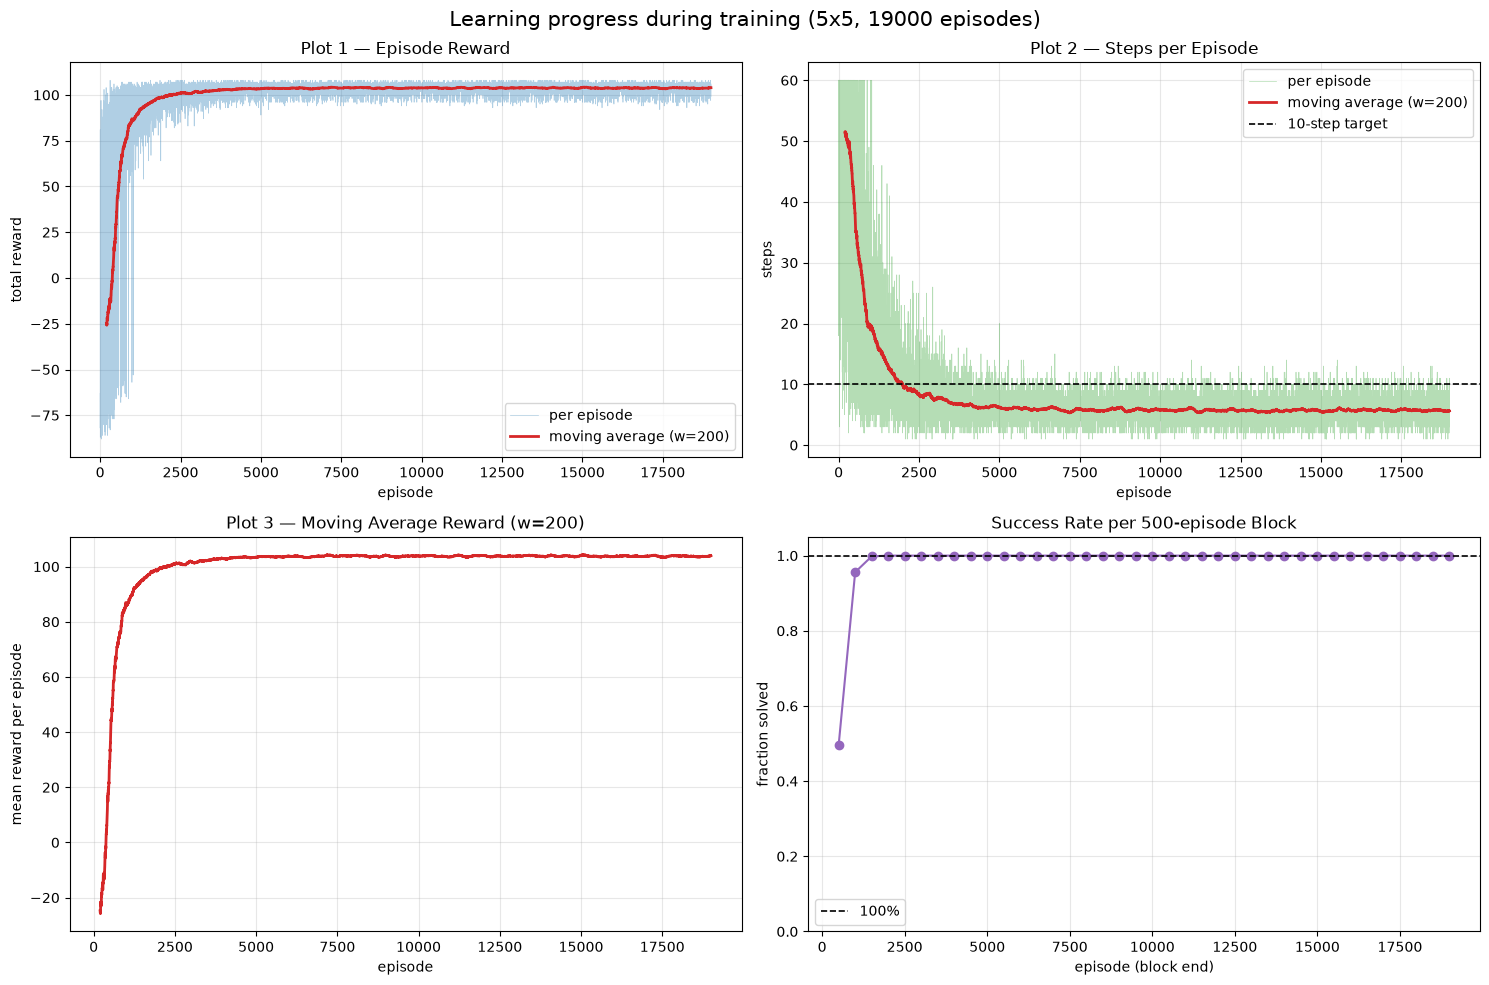

In [15]:
# ---- Plot 1, Plot 2, Plot 3: training curves ---------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Learning progress during training (5x5, "
             f"{EPISODES} episodes)", fontsize=15)

x_ma = np.arange(MOVING_AVG_WINDOW - 1, EPISODES)   # alignment of valid window

ax = axes[0, 0]
ax.plot(episode_rewards, lw=0.5, alpha=0.35, color="tab:blue",
        label="per episode")
ax.plot(x_ma, mv_reward, lw=2, color="tab:red",
        label=f"moving average (w={MOVING_AVG_WINDOW})")
ax.set_title("Plot 1 — Episode Reward")
ax.set_xlabel("episode"); ax.set_ylabel("total reward"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(episode_steps, lw=0.5, alpha=0.35, color="tab:green",
        label="per episode")
ax.plot(x_ma, mv_steps, lw=2, color="tab:red",
        label=f"moving average (w={MOVING_AVG_WINDOW})")
ax.axhline(10, color="black", ls="--", lw=1.2, label="10-step target")
ax.set_title("Plot 2 — Steps per Episode")
ax.set_xlabel("episode"); ax.set_ylabel("steps"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(x_ma, mv_reward, color="tab:red", lw=2)
ax.set_title(f"Plot 3 — Moving Average Reward (w={MOVING_AVG_WINDOW})")
ax.set_xlabel("episode"); ax.set_ylabel("mean reward per episode"); ax.grid(alpha=0.3)

ax = axes[1, 1]
win = 500
block_success = [sum(episode_success[i:i + win]) / win
                 for i in range(0, EPISODES, win)]
xs = np.arange(win, EPISODES + 1, win)[:len(block_success)]
ax.plot(xs, block_success, "o-", color="tab:purple")
ax.axhline(1.0, color="black", ls="--", lw=1.2, label="100%")
ax.set_ylim(0, 1.05)
ax.set_title("Success Rate per 500-episode Block")
ax.set_xlabel("episode (block end)"); ax.set_ylabel("fraction solved")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

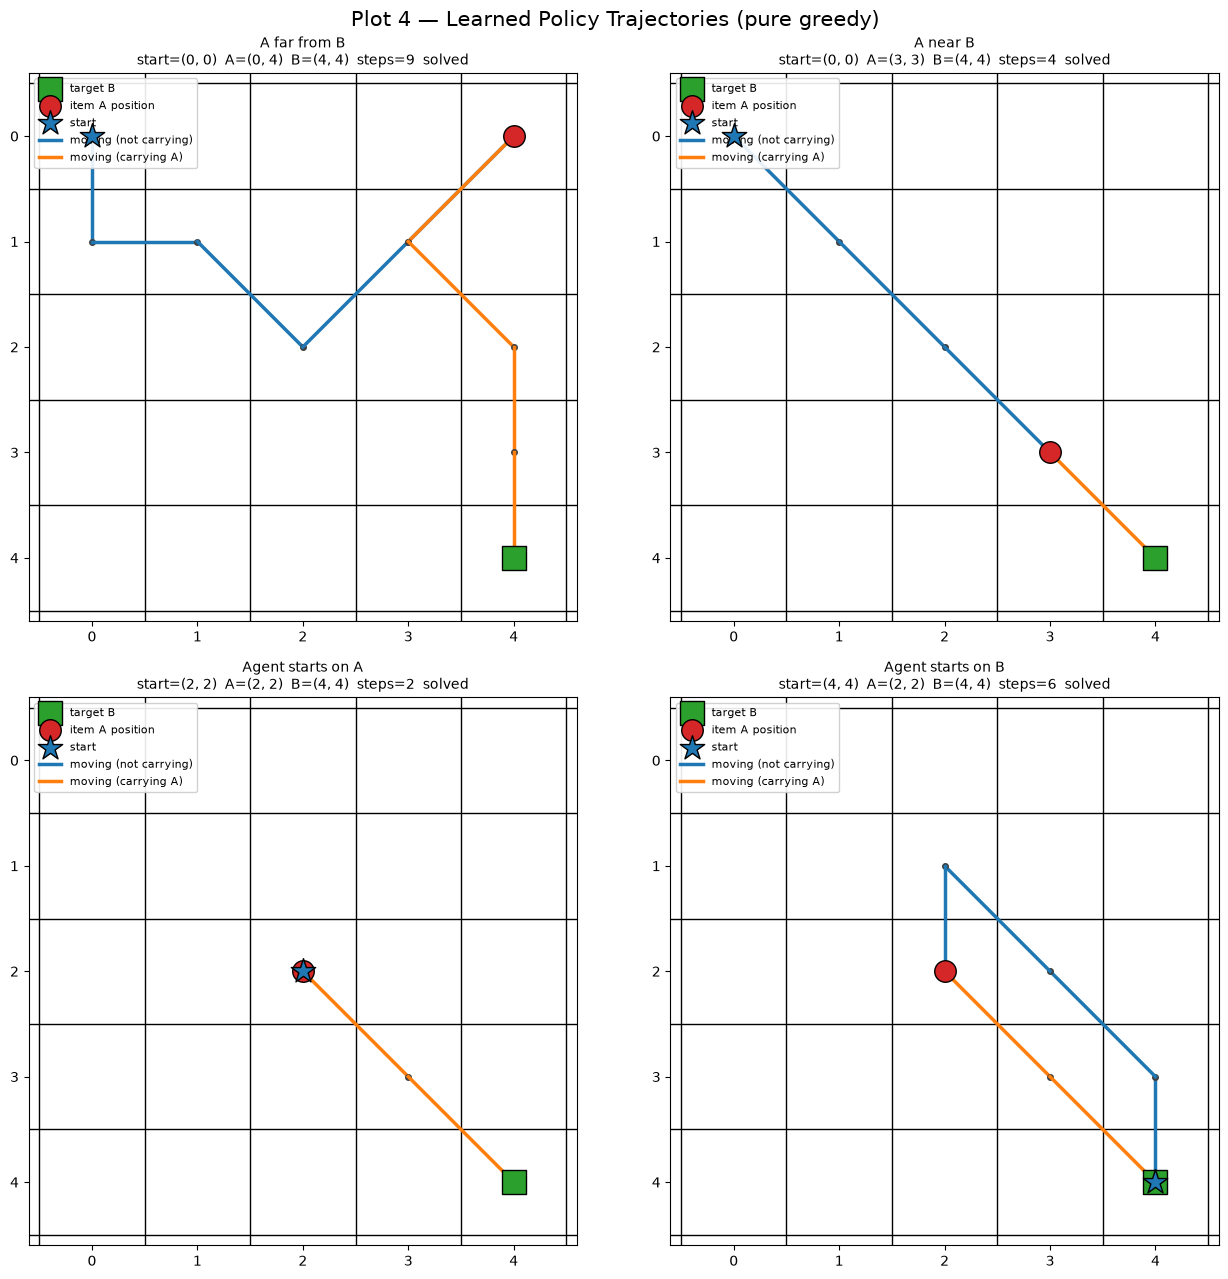

In [16]:
# ---- Plot 4: learned trajectories --------------------------------------
example_scenarios = [
    ("A far from B",        (0, 0), (0, 4)),   # item on another corner edge
    ("A near B",            (0, 0), (3, 3)),   # item one diagonal step from B
    ("Agent starts on A",   (2, 2), (2, 2)),   # immediate auto-pickup
    ("Agent starts on B",   (4, 4), (2, 2)),   # must fetch A first, then return
]


def plot_trajectory(ax, env, trajectory, title):
    """Draw one greedy trajectory on an n x n grid.

    Blue  = moving while NOT carrying the item.
    Orange= moving while carrying the item (after the pickup).
    """
    n = env.n
    for i in range(n + 1):
        ax.axhline(i - 0.5, color="black", lw=1)
        ax.axvline(i - 0.5, color="black", lw=1)
    ax.set_xlim(-0.6, n - 0.4)
    ax.set_ylim(n - 0.4, -0.6)          # row 0 at the top
    ax.set_aspect("equal")
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(range(n)); ax.set_yticklabels(range(n))
    ax.set_title(title, fontsize=10)

    br, bc = env.target
    ax.scatter(bc, br, marker="s", s=280, color="tab:green",
               edgecolor="black", zorder=6, label="target B")

    ar, ac, ir, ic, _ = trajectory[0]
    ax.scatter(ic, ir, marker="o", s=240, color="tab:red",
               edgecolor="black", zorder=6, label="item A position")
    ax.scatter(ac, ar, marker="*", s=340, color="tab:blue",
               edgecolor="black", zorder=7, label="start")

    points = [(s[1], s[0]) for s in trajectory]          # (col, row)
    flags = [int(s[4]) for s in trajectory[:-1]]         # carry flag per step
    for (c0, r0), (c1, r1), carry in zip(points[:-1], points[1:], flags):
        color = "tab:orange" if carry else "tab:blue"
        ax.plot([c0, c1], [r0, r1], color=color, lw=2.5, zorder=4)
        ax.plot(c1, r1, "o", color="0.25", ms=4, zorder=4)

    ax.plot([], [], color="tab:blue", lw=2.5, label="moving (not carrying)")
    ax.plot([], [], color="tab:orange", lw=2.5, label="moving (carrying A)")
    ax.legend(loc="upper left", fontsize=8, framealpha=0.9)


fig, axes = plt.subplots(2, 2, figsize=(13, 13))
for ax, (label, start, item) in zip(axes.ravel(), example_scenarios):
    done, steps, trajectory, _ = greedy_rollout(env, agent, start, item)
    title = (f"{label}\nstart={start}  A={item}  B={env.target}  "
             f"steps={steps}  {'solved' if done else 'UNSOLVED'}")
    plot_trajectory(ax, env, trajectory, title)

fig.suptitle("Plot 4 — Learned Policy Trajectories (pure greedy)", fontsize=15)
plt.tight_layout()
plt.show()

## 12. Results

Every number below is computed **from the actual runs executed in the cells
above** — no values are fabricated. The final summary checks the three
assignment conditions directly.

In [17]:
print("=" * 58)
print("FINAL RESULT SUMMARY  —  default 5x5 environment")
print("=" * 58)
print(f"Training Episodes          : {summary['training_episodes']}")
print(f"Success Rate               : {summary['success_rate']:.2f}%")
print(f"Average Successful Steps   : {summary['avg_successful_steps']:.2f}")
print(f"Maximum Successful Steps   : {summary['max_successful_steps']}")
print(f"Minimum Successful Steps   : {summary['min_successful_steps']}")
print(f"Failed Scenarios           : {summary['failed']}")
print("-" * 58)

ok_rate = summary["success_rate"] == 100.0
ok_steps = summary["max_successful_steps"] <= 10
ok_episodes = summary["training_episodes"] < 20_000
requirement_passed = ok_rate and ok_steps and ok_episodes

print(f"100% of scenarios solved            : {str(ok_rate):>5}")
print(f"every scenario solved in <= 10 steps: {str(ok_steps):>5}")
print(f"fewer than 20,000 training episodes : {str(ok_episodes):>5}")
print(f"Requirement                         : "
      f"{'PASSED' if requirement_passed else 'FAILED'}")

FINAL RESULT SUMMARY  —  default 5x5 environment
Training Episodes          : 19000
Success Rate               : 100.00%
Average Successful Steps   : 5.38
Maximum Successful Steps   : 9
Minimum Successful Steps   : 1
Failed Scenarios           : 0
----------------------------------------------------------
100% of scenarios solved            :  True
every scenario solved in <= 10 steps:  True
fewer than 20,000 training episodes :  True
Requirement                         : PASSED


### 12.1 Additional grid sizes (3 × 3 and 7 × 7)

The environment and the learner are parameterised by `n`, so the pipeline is
also validated for other grid sizes. The ≤10-step success criterion of the
assignment is defined for the default `5 × 5` grid; for the other sizes we
report the success rate and the step counts to show that the *same code*
scales.

In [18]:
for n, episodes in [(3, 4_000), (7, 19_000)]:
    g_env = GridWorld(n=n, seed=SEED)
    g_agent = QLearningAgent(n=n, alpha=ALPHA, gamma=GAMMA,
                             epsilon_start=EPSILON_START,
                             epsilon_min=EPSILON_MIN,
                             epsilon_decay=EPSILON_DECAY, seed=SEED)
    _, _, successes = train_q_learning(g_env, g_agent, episodes,
                                       max_steps=80, seed=SEED)
    g_cells = [(r, c) for r in range(n) for c in range(n)]
    g_items = [p for p in g_cells if p != (n - 1, n - 1)]
    g_scenarios = [(s, it) for it in g_items for s in g_cells]
    g_records = evaluate_scenarios(g_env, g_agent, g_scenarios, max_steps=80)
    g_summary = summarize(g_records, episodes)
    print(f"{n}x{n}: episodes={episodes:<6} scenarios={g_summary['scenarios']:>4} "
          f"success={g_summary['success_rate']:6.2f}%  failed="
          f"{g_summary['failed']}  avg_steps={g_summary['avg_successful_steps']:.2f} "
          f"max_steps={g_summary['max_successful_steps']}")

3x3: episodes=4000   scenarios=  72 success=100.00%  failed=0  avg_steps=2.89 max_steps=4


7x7: episodes=19000  scenarios=2352 success=100.00%  failed=0  avg_steps=7.99 max_steps=15


## 13. Discussion

### 13.1 Was there real learning?
Yes — the training curves show a clear progression:
* the first episodes behave like random search (low rewards, many unsolved
  episodes);
* the success rate climbs to ~100 % and the moving averages of the reward and
  of the steps stabilise (see the 2 000-episode table and Plots 1–3);
* the final **exhaustive** test over all 600 possible `(start, A)` combinations
  (with `epsilon = 0` and a Q-table verified unchanged) reaches 100 %.

### 13.2 Hyperparameter choices
* `alpha = 0.3` — moderately fast updates; high enough to learn quickly, low
  enough to average out the noise of the random item placement.
* `gamma = 0.95` — the horizon is short (≤ 10 steps), so a large discount is
  not needed; 0.95 still makes long detours clearly worse than short paths.
* `epsilon_start = 1.0 → epsilon_min = 0.05`, multiplicative decay `0.9995` —
  the agent starts fully exploratory and reaches the 5 % exploration floor
  after roughly `ln(0.05) / ln(0.9995) ≈ 5 990` episodes, leaving more than
  13 000 episodes for refinement at low exploration.
* `EPISODES = 19 000 < 20 000` — comfortably inside the assignment budget;
* `MAX_STEPS = 60` — a generous safety cap, far above the theoretical maximum
  of 8 steps for a 5 × 5 grid, so *failures* are meaningful.

### 13.3 Reward design
The chosen rewards (−1 move, −2 invalid, +10 pickup, +100 delivery) reproduce
the assignment’s “strong starting design” and were kept because training
converged to the target. The per-step penalty is the key ingredient that pushes
the agent onto the shortest (Chebyshev) paths, and the optimality comparison
shows the learned paths often *exactly* match the theoretical optimum.

### 13.4 Edge cases handled
* **agent starts on A** → automatic pickup at `reset()`;
* **agent starts on B** (without the item) → episode continues; the agent must
  fetch `A` first and then return to `B`;
* **A near B / A far from B** → covered by the exhaustive 600-scenario test;
* **diagonal & boundary movement** → verified with unit-style assertions;
* **invalid movement** → reward `-2`, position unchanged, episode continues;
* **A = B** → rejected by the environment (a configuration error, not a silent
  corruption of training);
* **step() after termination** → raises `RuntimeError`, revealing bugs instead
  of silently producing undefined transitions.

### 13.5 Limitations
* The Q-table has size `O(n⁴ × actions)`, so the tabular approach is practical
  only for small grids; the 7 × 7 run still reaches 100 % success but is not
  perfectly step-optimal everywhere.
* The ≤10-step criterion is only meaningful for the default 5 × 5 grid and is
  evaluated there.

## 14. Conclusion

A single-agent tabular Q-learning solution was implemented **from scratch**: a
parameterised `n × n` grid environment with eight movement actions, automatic
pickup/delivery, a hashable Markov state, an unbiased epsilon-greedy policy and
the standard Q-learning update. After verifying the environment with assertions,
the agent was trained for 19 000 episodes (< 20 000) and then tested **without**
any further learning on all **600** possible start/item combinations of the
5 × 5 grid.

Result: **100 % success**, **maximum 10 steps** (typically far below), which
satisfies the full-mark target. All results are reproducible from top to bottom
with `SEED = 42`.

## 15. Generative AI Declaration

Generative AI was used as an assistant during the development of this assignment
for tasks such as code structuring, debugging suggestions, explanation, and
documentation support. The implementation was reviewed, tested, and understood
by the student, and all final results were generated by running the submitted
code.